In [92]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel


data = np.genfromtxt(
    "PS_2026.04.21_03.28.15.csv",
    delimiter=",",
    comments="#",
    dtype=float,
    filling_values=np.nan
)


data = np.delete(data, [1,2,3,7,9,10,11], axis=1) #delete errors and limit flag

data1 = []

for n in range(len(data)):
    if (np.isnan(data[n,:]).any() == False):
        data1.append(data[n, :])

data1 = np.array(data1)
data2  = np.array(data1)

for n in range(len(data2)):
    data2[n,2] = (data2[n,2] - data2[n,3])/2 #take the mean of the 2 errors

sample_a = np.delete(data2,3, axis = 1)

In [93]:
print("number of planets in the dataset: ", len(sample_a))

number of planets in the dataset:  2914


In [94]:
#sample_a[:,0] #planet radius
#sample_a[:,1] #planet mass
#sample_a[:,2] #error an planetary mass
#sample_a[:,3] #stellar mass

In [95]:
sample_b = []
for n in range(len(sample_a)):
    if (sample_a[n,0] <= 5):
        sample_b.append(sample_a[n,0])
sample_b = np.array(sample_b)

In [96]:
print("number of planets in sample b: ", len(sample_b))

number of planets in sample b:  1145


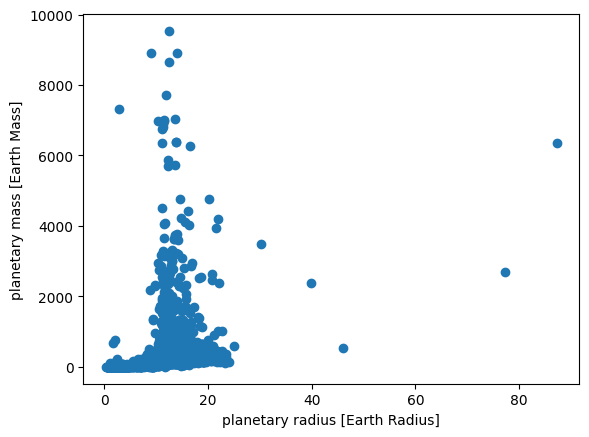

In [97]:
plt.scatter(sample_a[:,0], sample_a[:,1])
#plt.xscale('log')
#plt.yscale('log')
plt.xlabel('planetary radius [Earth Radius]')
plt.ylabel('planetary mass [Earth Mass]')
plt.savefig('planradmassnolog.png')

In [98]:
planet_r = sample_a[:, 0].copy()
planet_m = sample_a[:, 1].copy()
error_m = sample_a[:, 2].copy()
stellar_m = sample_a[:, 3].copy()

# log Transformation
log_planet_r = np.log10(planet_r)
log_stellar_m = np.log10(stellar_m)
log_planet_m = np.log10(planet_m)
log_error_m = error_m / (planet_m * np.log(10)) # relative error (we can't just apply logarithmic transformation to the error)

log_sample_a = np.column_stack((log_planet_r, log_planet_m, log_error_m, log_stellar_m))

In [99]:
(sample_a[:,1] == data2[:,1]).all()

np.True_

In [100]:
(log_sample_a[:,2] == log_error_m).all()

np.True_

In [101]:
#sample_a[:,0] #planet radius
#sample_a[:,1] #planet mass
#sample_a[:,2] #error an planetary mass
#sample_a[:,3] #stellar mass

In [102]:
#derive log sample_b:

log_sample_b = []
for n in range(len(log_sample_a)):
    if (log_sample_a[n,0] <= np.log(5)):
        log_sample_b.append(log_sample_a[n,:])
log_sample_b = np.array(log_sample_b)

## Single Kernel Model

Ignoring the uncertainties associated with the mass measurements, use a 1D linear regression model
to fit sample_B:

In [103]:
X = log_sample_a[:,0].copy()
Y = log_sample_a[:,1].copy()

X = X.reshape(-1,1)
Y = Y.reshape(-1,1)

alpha = log_sample_a[:,2].copy()
alpha = (alpha)**2


#kernel = RBF(length_scale=0.01)

kernel = ConstantKernel(constant_value=1.0, constant_value_bounds="fixed")*RBF(
    length_scale=1,
    length_scale_bounds=(0.3, 10)
)

gp_single = GaussianProcessRegressor(
    kernel=kernel,
    alpha= alpha,
    normalize_y=False
)

gp_single.fit(X, Y)

c:\Users\ahmet\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.3. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


GaussianProcessRegressor(alpha=array([0.02651657, 0.0011812 , 0.00038876, ..., 0.00605706, 0.00499836,
       0.0058656 ]),
                         kernel=1**2 * RBF(length_scale=1))

In [104]:
print(gp_single.kernel_)

1**2 * RBF(length_scale=0.3)


In [105]:
x_pred_single = np.linspace(log_sample_a[:,0].min(), log_sample_a[:,0].max(), 300).reshape(-1, 1)

y_pred_single, y_std = gp_single.predict(x_pred_single, return_std=True)

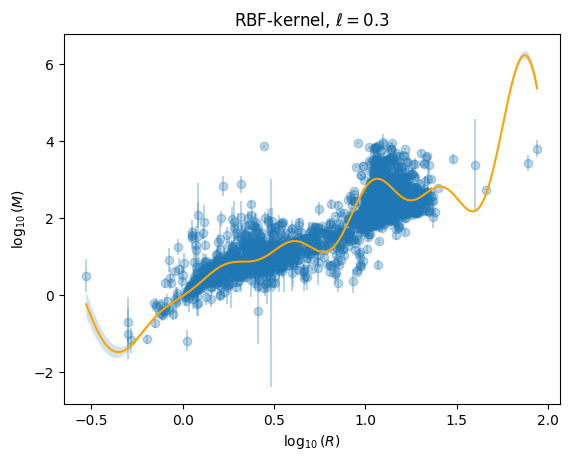

In [106]:
plt.plot(x_pred_single, y_pred_single, color='orange', zorder=3)
plt.errorbar(log_sample_a[:,0], log_sample_a[:,1], yerr=log_sample_a[:,2], fmt='o', alpha=0.3)

plt.fill_between(
    x_pred_single.flatten(),
    y_pred_single - y_std,
    y_pred_single + y_std,
    alpha=0.2
)

plt.xlabel('$\log_{10}(R)$')
plt.ylabel('$\log_{10}(M)$')
plt.title(f"RBF-kernel, $\ell = ${0.3}")
plt.savefig("firstplot.png")

c:\Users\ahmet\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\ahmet\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\ahmet\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
c

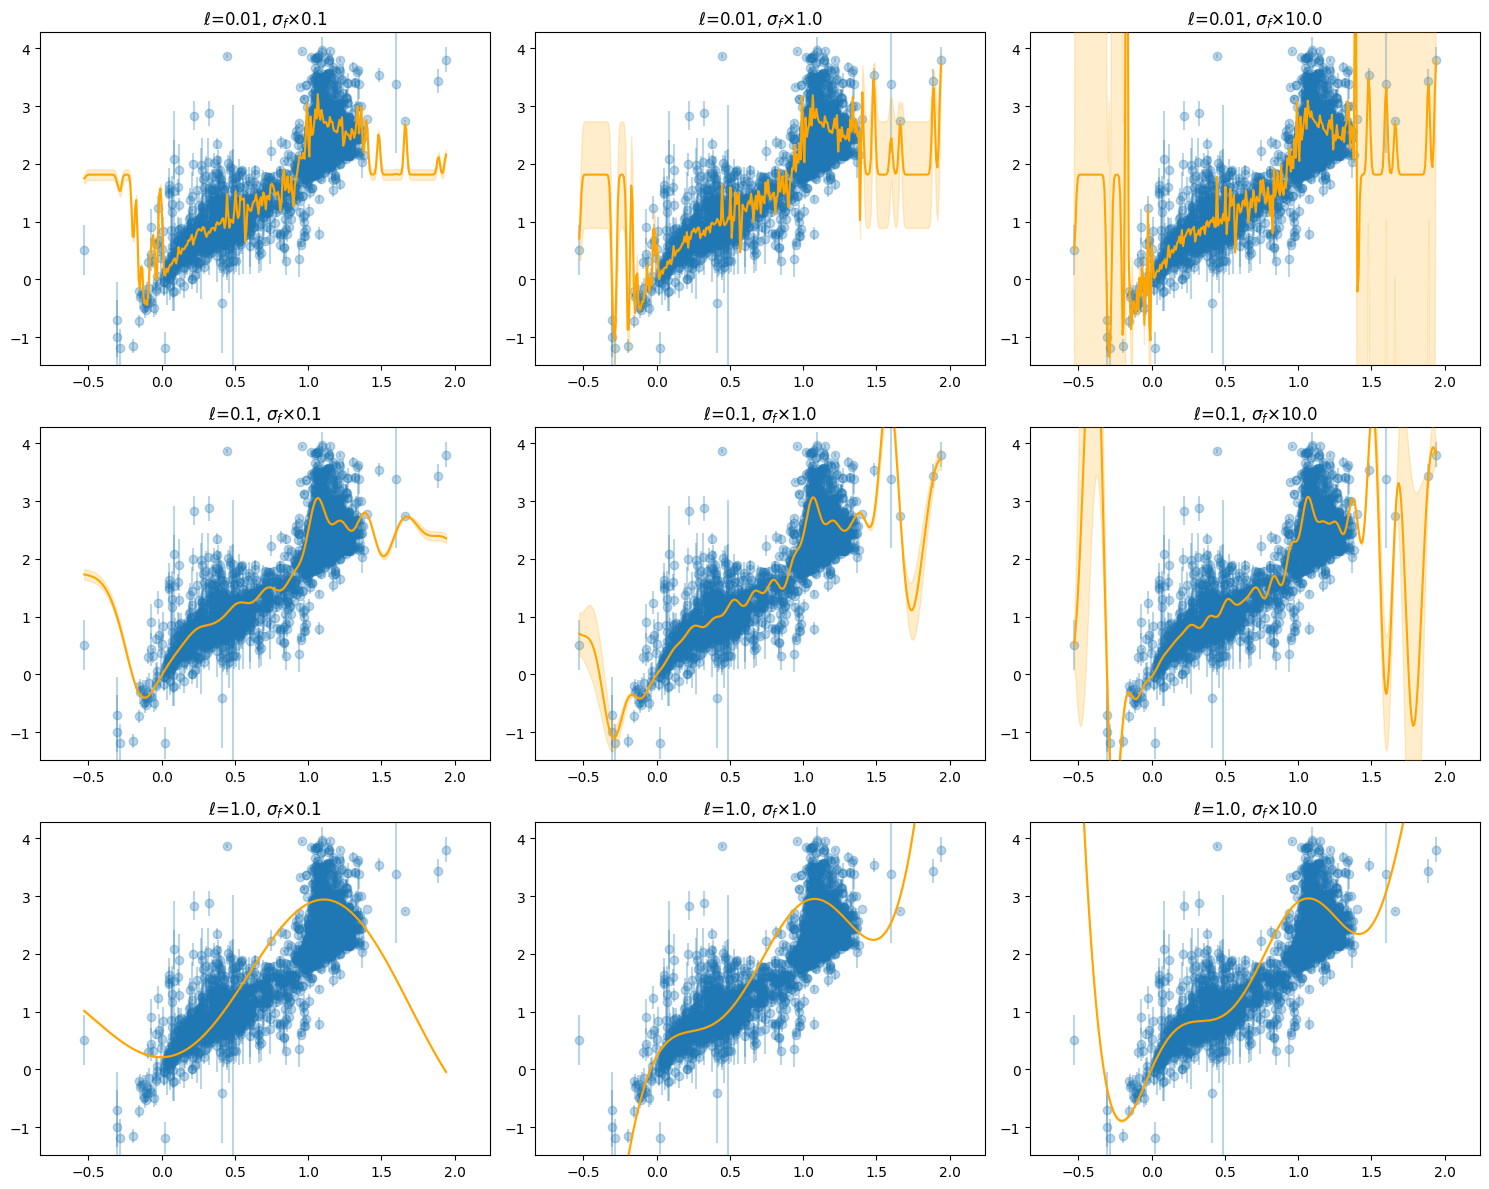

In [107]:
X = log_sample_a[:,0].reshape(-1,1)
Y = log_sample_a[:,1]

alpha = (log_sample_a[:,2])**2

length_scales = [0.01, 0.1, 1.0]
noise_scales =[0.1, 1.0, 10.0]

fig, axs = plt.subplots(3, 3, figsize=(15, 12))

x_pred = np.linspace(X.min(), X.max(), 300).reshape(-1, 1)

for i, l in enumerate(length_scales):
    for j, ns in enumerate(noise_scales):

        kernel = ConstantKernel(constant_value=ns**2, constant_value_bounds="fixed") * RBF(length_scale=1.0,
                    length_scale_bounds = (l, 10))

        gp = GaussianProcessRegressor(
            kernel=kernel,
            alpha=alpha,
            normalize_y=True
        )

        gp.fit(X, Y)

        y_pred, y_std = gp.predict(x_pred, return_std=True)

        ax = axs[i, j]

        #ax.scatter(X, Y, alpha=0.3)
        ax.errorbar(X, Y, yerr=log_sample_a[:,2], fmt='o', alpha=0.3, zorder=1)

        ax.plot(x_pred, y_pred, color = "orange")
        ax.fill_between(
            x_pred.flatten(),
            y_pred - y_std,
            y_pred + y_std,
            color = "orange",
            alpha=0.2,
            zorder=3
        )

        ax.set_title(f"ℓ={l}, $\sigma_f$×{ns}")
        ax.set_xlim(X.min()-0.3, X.max()+0.3)
        ax.set_ylim(Y.min()-0.3, Y.max()+0.3)

plt.tight_layout()
plt.savefig("singlekernelmultparam.png")
plt.show()

In [108]:

X = log_sample_a[:,0].copy()
Y = log_sample_a[:,1].copy()

X = X.reshape(-1,1)
Y = Y.reshape(-1,1)

alpha = log_sample_a[:,2].copy()
alpha = (alpha)**2


kernel = (
    ConstantKernel(0.05**2, (0.01, 0.05)) * RBF(0.1, length_scale_bounds="fixed")
    + ConstantKernel(1.0**2, (0.1, 2)) * RBF(0.3, length_scale_bounds="fixed")
    + ConstantKernel(5**2, (10, 100)) * RBF(1, length_scale_bounds="fixed")
)

gp_3 = GaussianProcessRegressor(
    kernel=kernel,
    alpha=alpha,
    normalize_y=True,
    n_restarts_optimizer=5
)


gp_3.fit(X, Y)
print(gp_3.kernel_)


c:\Users\ahmet\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__k1__constant_value is close to the specified upper bound 0.05. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\ahmet\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__k1__constant_value is close to the specified lower bound 10. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


0.224**2 * RBF(length_scale=0.1) + 0.534**2 * RBF(length_scale=0.3) + 3.16**2 * RBF(length_scale=1)


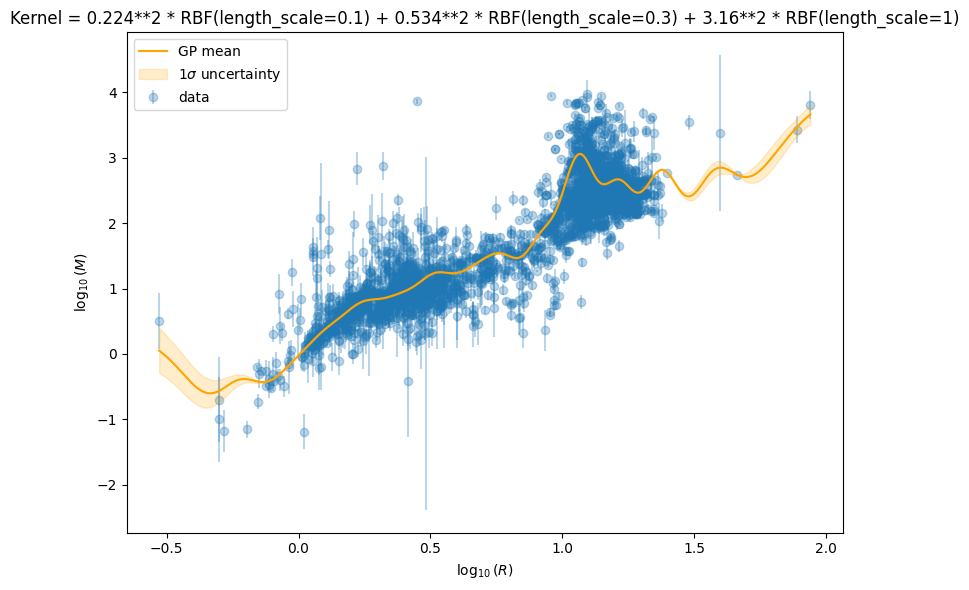

In [109]:
x3_pred = np.linspace(
    log_sample_a[:,0].min(),
    log_sample_a[:,0].max(),
    300
).reshape(-1, 1)

y3_pred, y_std = gp_3.predict(x3_pred, return_std=True)

x3_plot = x3_pred.ravel()
y3_plot = y3_pred.ravel()
std_plot = y_std.ravel()

plt.figure(figsize=(8, 6))

plt.errorbar(
    log_sample_a[:,0],
    log_sample_a[:,1],
    yerr=log_sample_a[:,2],
    fmt='o',
    alpha=0.3,
    zorder=1,
    label="data"
)

plt.plot(
    x3_plot,
    y3_plot,
    color='orange',
    zorder=3,
    label="GP mean"
)

plt.fill_between(
    x3_plot,
    y3_plot - std_plot,
    y3_plot + std_plot,
    color='orange',
    alpha=0.2,
    zorder=2,
    label=r"$1\sigma$ uncertainty"
)

plt.xlabel(r'$\log_{10}(R)$')
plt.ylabel(r'$\log_{10}(M)$')
plt.title(f"Kernel = {gp_3.kernel_}")



plt.legend()
plt.tight_layout()
plt.savefig("firstplot.png", dpi=200)
plt.show()


In [110]:
solar_planets = np.array([[2439.4, 0.330103e24, 0.000021e24],   #mean radius (because I think it says more about mass
                          [6051.8, 4.86731e24, 0.00023e24],
                          [6371.0084, 5.97217e24, 0.00028e24],
                          [3389.50, 0.641691e24, 0.000030e24],
                          [69911, 1898.125e24, 0.088e24],
                          [58232, 568.317e24, 0.026e24],
                          [25362, 86.8099e24, 0.0040e24],
                          [24622, 102.4092e24, 0.0048e24]])

solar_planets[:,0] = solar_planets[:,0] / 6378 #converting radius km -> earth radius
solar_planets[:,1] = solar_planets[:,1] /5.972e+24
solar_planets[:,2] = solar_planets[:,2] /5.972e+24

solarplanet_r = solar_planets[:, 0].copy() #apply logarithmic transformation
solarplanet_m = solar_planets[:, 1].copy()
solarerror_m = solar_planets[:, 2].copy()


# log10 transformation
log_solarplanet_r = np.log10(solarplanet_r)
log_solarplanet_m = np.log10(solarplanet_m)

# error propagation for log10(M)
log_solarerror_m = solarerror_m / (solarplanet_m * np.log(10))

x_solar = log_solarplanet_r.reshape(-1, 1)
y_solar_true = log_solarplanet_m


In [111]:
y_solar = gp_single.predict(x_solar).ravel()
y_solar_3 = gp_3.predict(x_solar).ravel()

def linear_model(x, a, b):
    return a * x + b
popt, pcov = curve_fit(
    linear_model,
    log_sample_b[:,0],
    log_sample_b[:,1],
    sigma=log_sample_b[:,2],
    absolute_sigma=True
)
a_3, b_3 = popt

#MLE linear model
x_fit = np.linspace(min(log_sample_b[:,0]), max(log_sample_b[:,0]), 100)
y_fit = linear_model(x_fit, a_3, b_3)
y_lm_solar = linear_model(x_solar.ravel(), a_3, b_3)


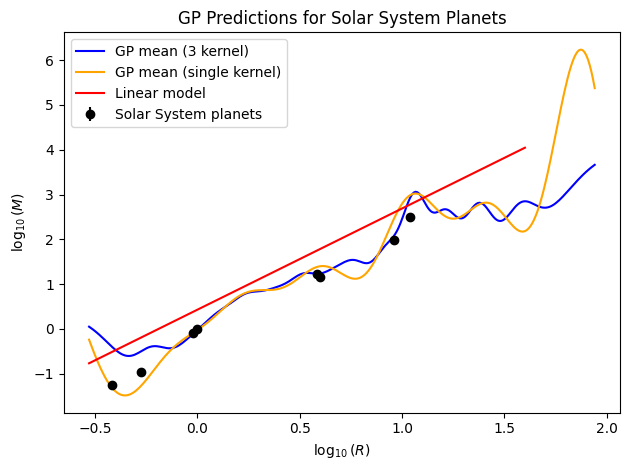

MSE for single kernel GP: 0.0803
MSE for multi-kernel GP: 0.1461
MSE for linear model: 0.3340


In [112]:

plt.errorbar(
    x_solar.ravel(),
    y_solar_true,
    yerr=log_solarerror_m,
    fmt='o',
    color='black',
    label='Solar System planets',
    zorder=5
)
plt.plot(
    x3_pred.ravel(),
    y3_pred.ravel(),
    color='blue',
    label='GP mean (3 kernel)',
    zorder=3
)
plt.plot(
    x_pred_single.ravel(),
    y_pred_single.ravel(),
    color='orange',
    label='GP mean (single kernel)',
    zorder=3
)
plt.plot(
    x_fit,
    y_fit,
    color='red',
    label='Linear model',
    zorder=3
)
plt.xlabel(r'$\log_{10}(R)$')
plt.ylabel(r'$\log_{10}(M)$')
plt.title("GP Predictions for Solar System Planets")
plt.legend()
plt.tight_layout()
plt.savefig("solar_system_predictions.png", dpi=200)
plt.show()

MSE_single = np.mean((y_solar - y_solar_true)**2)
MSE_multi = np.mean((y_solar_3 - y_solar_true)**2)
print(f"MSE for single kernel GP: {MSE_single:.4f}")
print(f"MSE for multi-kernel GP: {MSE_multi:.4f}")
def linear_model(x, a, b):
    return a * x + b


MSE_lm = np.mean((y_lm_solar - y_solar_true)**2)
print(f"MSE for linear model: {MSE_lm:.4f}")


In [113]:
y_train_single = gp.predict(X).ravel()
y_train_multi = gp_3.predict(X).ravel()

MSE_single_train = np.mean((y_train_single - Y.ravel())**2)
MSE_multi_train = np.mean((y_train_multi - Y.ravel())**2)

print(f"Single-kernel GP training MSE: {MSE_single_train:.4f}")
print(f"Multi-kernel GP training MSE: {MSE_multi_train:.4f}")


Single-kernel GP training MSE: 0.2871
Multi-kernel GP training MSE: 0.1798


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel
from scipy.optimize import curve_fit
import numpy as np

# ---------- Data ----------

X_all = log_sample_a[:, 0].reshape(-1, 1)
Y_all = log_sample_a[:, 1]
alpha_all = log_sample_a[:, 2]**2   # variance of log mass errors

X_train, X_test, Y_train, Y_test, alpha_train, alpha_test = train_test_split(
    X_all,
    Y_all,
    alpha_all,
    test_size=0.2,
    random_state=42
)

# ---------- Linear model ----------

def linear_model(x, a, b):
    return a * x + b

popt_lm, pcov_lm = curve_fit(
    linear_model,
    X_train.ravel(),
    Y_train,
    sigma=np.sqrt(alpha_train),
    absolute_sigma=True
)

Y_pred_lm = linear_model(X_test.ravel(), *popt_lm)

mse_lm = np.mean((Y_pred_lm - Y_test)**2)
weighted_mse_lm = np.mean((Y_pred_lm - Y_test)**2 / alpha_test)

# ---------- Single-kernel GP ----------

kernel_single = RBF(
    length_scale=1.0,
    length_scale_bounds=(0.3, 10)
)

gp_single = GaussianProcessRegressor(
    kernel=kernel_single,
    alpha=alpha_train,
    normalize_y=True
)

gp_single.fit(X_train, Y_train)

Y_pred_single, std_single = gp_single.predict(X_test, return_std=True)

mse_single = np.mean((Y_pred_single - Y_test)**2)
weighted_mse_single = np.mean((Y_pred_single - Y_test)**2 / alpha_test)
chi2_single_with_model_unc = np.mean(
    (Y_pred_single - Y_test)**2 / (alpha_test + std_single**2)
)

# ---------- Three-kernel GP ----------

kernel_3 = (
    ConstantKernel(0.05**2, (0.01, 0.05)) * RBF(0.1, length_scale_bounds="fixed")
    + ConstantKernel(1.0**2, (0.1, 2)) * RBF(0.3, length_scale_bounds="fixed")
    + ConstantKernel(5**2, (10, 100)) * RBF(1, length_scale_bounds="fixed")
)

gp_3 = GaussianProcessRegressor(
    kernel=kernel_3,
    alpha=alpha_train,
    normalize_y=True,
    n_restarts_optimizer=5
)

gp_3.fit(X_train, Y_train)

Y_pred_3, std_3 = gp_3.predict(X_test, return_std=True)

mse_3 = np.mean((Y_pred_3 - Y_test)**2)
weighted_mse_3 = np.mean((Y_pred_3 - Y_test)**2 / alpha_test)
chi2_3_with_model_unc = np.mean(
    (Y_pred_3 - Y_test)**2 / (alpha_test + std_3**2)
)

# ---------- Results ----------

print("Plain test MSE:")
print(f"Linear model:     {mse_lm:.4f}")
print(f"Single-kernel GP: {mse_single:.4f}")
print(f"Three-kernel GP:  {mse_3:.4f}")

print("\nWeighted test MSE / chi-square per point:")
print(f"Linear model:     {weighted_mse_lm:.4f}")
print(f"Single-kernel GP: {weighted_mse_single:.4f}")
print(f"Three-kernel GP:  {weighted_mse_3:.4f}")

print("\nGP chi-square including model uncertainty:")
print(f"Single-kernel GP: {chi2_single_with_model_unc:.4f}")
print(f"Three-kernel GP:  {chi2_3_with_model_unc:.4f}")

print("\nOptimized kernels:")
print("Single kernel:", gp_single.kernel_)
print("Three kernel:", gp_3.kernel_)


c:\Users\ahmet\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 0.3. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\ahmet\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__k1__constant_value is close to the specified upper bound 0.05. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\ahmet\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__k1__constant_value is close to the specified lower bound 10. Decreasing the bound and calling fit again may find a better value.
  warning

Plain test MSE:
Linear model:     0.3998
Single-kernel GP: 0.2008
Three-kernel GP:  0.1744

Weighted test MSE / chi-square per point:
Linear model:     383.1919
Single-kernel GP: 168.6688
Three-kernel GP:  149.1455

GP chi-square including model uncertainty:
Single-kernel GP: 168.1621
Three-kernel GP:  148.0467

Optimized kernels:
Single kernel: RBF(length_scale=0.3)
Three kernel: 0.224**2 * RBF(length_scale=0.1) + 0.466**2 * RBF(length_scale=0.3) + 3.16**2 * RBF(length_scale=1)


In [116]:
small_mask = X_test.ravel() <= np.log10(5)
large_mask = X_test.ravel() > np.log10(5)
mse_single_small = np.mean((Y_pred_single[small_mask] - Y_test[small_mask])**2)
mse_single_large = np.mean((Y_pred_single[large_mask] - Y_test[large_mask])**2)

mse_3_small = np.mean((Y_pred_3[small_mask] - Y_test[small_mask])**2)
mse_3_large = np.mean((Y_pred_3[large_mask] - Y_test[large_mask])**2)

print(f"Single-kernel GP MSE, small planets: {mse_single_small:.4f}")
print(f"Single-kernel GP MSE, large planets: {mse_single_large:.4f}")

print(f"Three-kernel GP MSE, small planets: {mse_3_small:.4f}")
print(f"Three-kernel GP MSE, large planets: {mse_3_large:.4f}")


Single-kernel GP MSE, small planets: 0.1102
Single-kernel GP MSE, large planets: 0.2569
Three-kernel GP MSE, small planets: 0.1147
Three-kernel GP MSE, large planets: 0.2114
